In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#병합 데이터 불러오기 & 확인

In [4]:
import pandas as pd

# CSV 파일 경로 설정
csv_file_path = "/content/drive/MyDrive/100만원/data/merge/total_to_merge.csv"

# CSV 파일을 DataFrame으로 불러오기
df = pd.read_csv(csv_file_path, index_col=0)

In [5]:
df

,WTCH_YM,ENN_LNN_MTH_AVG,평균파주기_MTH_AVG,해면수온_MTH_AVG,해상기온_MTH_AVG,해상풍_MTH_AVG,해면기압_MTH_AVG,해빙부피_MTH_AVG
0,198201,0.417152,0.438589,0.277211,0.262603,0.387240,0.161943,0.678500
1,198202,0.392071,0.540907,0.310910,0.364719,0.582365,0.283401,0.795634
2,198203,0.505233,0.583897,0.340307,0.405130,0.639749,0.631579,0.876078
3,198204,0.651475,0.652539,0.308418,0.332131,0.254644,0.708502,0.897472
4,198205,0.757367,0.296060,0.270942,0.449827,0.319642,0.453441,0.819460
...,...,...,...,...,...,...,...,...
496,202305,0.756239,0.635650,0.776816,0.898156,0.507759,0.611336,0.578157
497,202306,0.810477,0.356991,0.778622,0.941425,0.286319,0.736842,0.425725
498,202307,0.762018,0.332515,0.894336,1.000000,0.781480,0.862348,0.193700
499,202308,0.726991,0.499413,1.000000,0.980407,0.502232,0.842105,0.065829


#결측치 확인 및 처리

In [6]:
df.isna().sum()

WTCH_YM             0
ENN_LNN_MTH_AVG     0
평균파주기_MTH_AVG       0
해면수온_MTH_AVG       0
해상기온_MTH_AVG        0
해상풍_MTH_AVG    0
해면기압_MTH_AVG        0
해빙부피_MTH_AVG        2
dtype: int64

In [7]:
# null 값을 가지는 행 삭제
df = df.dropna()

In [8]:
df.isna().sum()

WTCH_YM             0
ENN_LNN_MTH_AVG     0
평균파주기_MTH_AVG       0
해면수온_MTH_AVG       0
해상기온_MTH_AVG        0
해상풍_MTH_AVG    0
해면기압_MTH_AVG        0
해빙부피_MTH_AVG        0
dtype: int64

In [9]:
#디렉토리 변경해주기
%cd /content/drive/MyDrive/100만원

/content/drive/.shortcut-targets-by-id/1Pr6ISrCPmJz-WN1lXdcGOp0oMel6wg7w/100만원


#ESN라이브러리 임포트

In [10]:
import pyESN
from pyESN import ESN
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

##종속변수, 독립변수 분리

In [11]:
features = ['ENN_LNN_MTH_AVG', '평균파주기_MTH_AVG', '해면수온_MTH_AVG', '해상기온_MTH_AVG', '해상풍_MTH_AVG', '해면기압_MTH_AVG']
data = df[features].values

data
# 결과 확인
#print(result_array)
#print(type(result_array))

array([[0.41715206, 0.43858874, 0.27721143, 0.2626029 , 0.38723963,
        0.16194332],
       [0.39207137, 0.54090676, 0.31090981, 0.36471869, 0.58236464,
        0.28340081],
       [0.50523322, 0.58389747, 0.34030679, 0.4051296 , 0.63974944,
        0.63157895],
       ...,
       [0.76201767, 0.33251544, 0.89433567, 1.        , 0.7814803 ,
        0.86234818],
       [0.7269914 , 0.49941333, 1.        , 0.98040683, 0.50223171,
        0.84210526],
       [0.74735516, 0.52550164, 0.93975551, 0.95611946, 0.60702467,
        0.65991903]])

In [12]:
target = df['해빙부피_MTH_AVG'].values
target

array([0.67849961, 0.79563424, 0.87607805, 0.89747214, 0.81945999,
       0.69241643, 0.45800974, 0.28353906, 0.21230581, 0.28452069,
       0.42906545, 0.60241988, 0.74985065, 0.87872567, 0.96489102,
       0.96304555, 0.88214177, 0.77054918, 0.54899074, 0.33418876,
       0.2618673 , 0.33047817, 0.45655411, 0.61079465, 0.74717779,
       0.86924585, 0.93958721, 0.9559469 , 0.88494644, 0.75300592,
       0.50945598, 0.32235021, 0.25184898, 0.30380006, 0.42898973,
       0.60494409, 0.76610096, 0.87143911, 0.96045402, 0.96785837,
       0.90897694, 0.75454568, 0.48638468, 0.31840683, 0.24601806,
       0.30331766, 0.43483468, 0.58262165, 0.75950436, 0.88666291,
       0.97072476, 0.95949482, 0.87030602, 0.76110302, 0.52283991,
       0.3429646 , 0.28781058, 0.37211083, 0.49138543, 0.63612651,
       0.80195879, 0.93521191, 0.98236418, 1.        , 0.92748782,
       0.80865917, 0.54273911, 0.31885558, 0.27063753, 0.3274379 ,
       0.46358825, 0.90462968, 0.97859469, 0.96375232, 0.87587

##7:3으로 train data와 test data 나누기

In [13]:
import numpy as np

N = len(df)
traintest_cutoff = int(np.ceil(0.7*N))
N
traintest_cutoff

350

In [14]:
train_X,train_Y = data[:traintest_cutoff],target[:traintest_cutoff]
test_X, test_Y  = data[traintest_cutoff:],target[traintest_cutoff:]

In [15]:
train_Y.shape #(350, )
train_X.shape #(350, 6)

(350, 6)

In [16]:
n_samples, n_features = train_X.shape #각 입력벡터(row)가 6개의 열을 가짐 => 입력데이터의 차원은 6

##ESN모델 생성

In [17]:
#ESN 기본 값 설정
n_reservoir= 500
sparsity=0.2
rand_seed=23
spectral_radius = 1.5
noise = .001

In [18]:
esn = ESN(n_inputs = n_features, #입력 차원의 수(=입력 데이터의 열 수)
      n_outputs = 1, #출력 차원의 수
      n_reservoir = n_reservoir, # reservoir 뉴런의 수
      sparsity=sparsity, # recurrent weights 중 0으로 설정되는 비율
      random_state=rand_seed, #난수 생성을 위한 시드값
      spectral_radius = spectral_radius, # recurrent weight matrix의 스펙트럴 반지름(고유값 중 최대 값)
      noise=noise )   #각 뉴런에 추가되는 노이즈(정규화) -> 과적합방지

#train 데이터를 이용하여 ESN 모델 훈련

In [19]:
# 훈련 데이터로 ESN 모델 훈련
esn.fit(train_X, train_Y)

array([[0.67849961],
       [0.79563424],
       [0.87607805],
       [0.89747214],
       [0.81945999],
       [0.69241643],
       [0.45800974],
       [0.28353906],
       [0.21230581],
       [0.28452069],
       [0.42906545],
       [0.60241988],
       [0.74985065],
       [0.87872567],
       [0.96489102],
       [0.96304555],
       [0.88214177],
       [0.77054918],
       [0.54899074],
       [0.33418876],
       [0.2618673 ],
       [0.33047817],
       [0.45655411],
       [0.61079465],
       [0.74717779],
       [0.86924585],
       [0.93958721],
       [0.9559469 ],
       [0.88494644],
       [0.75300592],
       [0.50945598],
       [0.32235021],
       [0.25184898],
       [0.30380006],
       [0.42898973],
       [0.60494409],
       [0.76610096],
       [0.87143911],
       [0.96045402],
       [0.96785837],
       [0.90897694],
       [0.75454568],
       [0.48638468],
       [0.31840683],
       [0.24601806],
       [0.30331766],
       [0.43483468],
       [0.582

## test data를 이용하여 예측

In [20]:
#예측 수행
pred_tot = esn.predict(test_X)
# 예측 결과 확인
print(pred_tot.flatten())

[ 0.57750059  0.5553665   0.35619043  0.2309506   0.1023758  -0.00531008
  0.05542931  0.20374191  0.45831891  0.64667078  0.84031789  0.78790718
  0.64936514  0.42860185  0.10681183  0.06299549  0.05160183  0.09391127
  0.22416883  0.30342613  0.46754351  0.61534911  0.77304654  0.85810231
  0.86134728  0.66933352  0.39841858  0.04173526  0.02709041 -0.00277454
  0.13572877  0.35770759  0.51133775  0.59268302  0.73016711  0.67896944
  0.63485409  0.56370815  0.29463558  0.166823    0.1264394   0.07895019
  0.23213118  0.41525428  0.57381251  0.75245787  0.87381075  0.889973
  0.82445375  0.64661089  0.42308729  0.27460932  0.23879707  0.32409876
  0.50771742  0.69341641  0.80935001  0.96274018  1.11401813  1.07256815
  1.01632747  0.92582472  0.75771404  0.50849655  0.4333563   0.36489923
  0.42698074  0.63059045  0.65937527  0.71831089  0.8372016   0.82449862
  0.81452586  0.6419881   0.46805617  0.34191786  0.24655193  0.23442669
  0.28826474  0.43839554  0.61820283  0.70587876  0.6

##예측 결과 확인하기

In [21]:
from sklearn.metrics import mean_squared_error

# 실제 값과 예측 값 간의 MSE 계산
mse = mean_squared_error(test_Y, pred_tot)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.037604094184348874


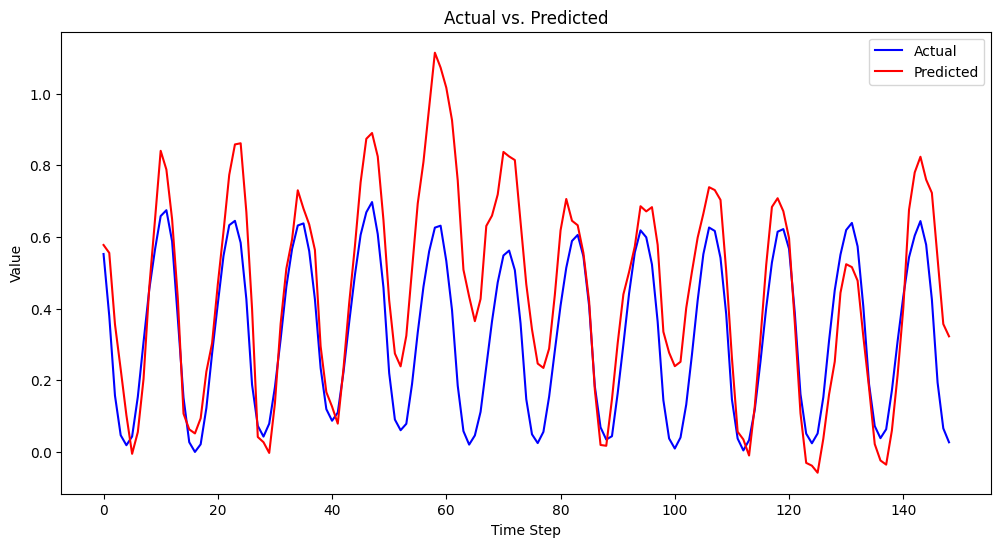

In [22]:
import matplotlib.pyplot as plt

# 시각화: 실제 값과 예측 값 그래프
plt.figure(figsize=(12, 6))
plt.plot(test_Y, label="Actual", color="blue")  # 실제 값 선 색상: 파란색
plt.plot(pred_tot, label="Predicted", color="red")  # 예측 값 선 색상: 빨간색
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title("Actual vs. Predicted")
plt.legend()
plt.show()

#파라미터 최적화를 통한 더 좋은 예측 모델 만들기

In [25]:
#훈련 데이터 설정
trainlen = len(train_X) #훈련 데이터의 길이
futureTotal=len(test_X) #예측할 미래 데이터의 전체 수
pred_tot=np.zeros(futureTotal) #예측결과를 저장할 배열

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 기존 설정(default)
n_reservoir = 500
rand_seed = 23

# 다양한 sparsity, 반지름, 노이즈 설정 준비 (조정할 파라미터들)
sparsity_set = [0.05, 0.1, 0.2, 0.3, 0.4]
radius_set = [0.5, 0.7, 0.9,  1,  1.1,1.3,1.5] # 순환 가중치 행렬의 스펙트럴 반지름 설정
n_reservoir_set = [500, 1000, 2000] # 각 뉴런에 추가되는 노이즈 설정

# 설정된 값들의 크기 계산
sparsity_set_size = len(sparsity_set)
radius_set_size = len(radius_set)
n_reservoir_size = len(n_reservoir_set)

# MSE 값 저장할 3D 배열 초기화
loss = np.zeros([sparsity_set_size, radius_set_size, n_reservoir_size])

# sparsity, 반지름, 노이즈 설정 반복
for s in range(sparsity_set_size):
    sparsity = sparsity_set[s]
    for l in range(radius_set_size):
        rho = radius_set[l]
        for j in range(n_reservoir_size):
            n_reservoir = n_reservoir_set[j]

            pred_tot = np.zeros(futureTotal)  # 예측 결과 저장 배열 초기화

            # 랜덤으로 생성된 값 esn 모델에 적용
            esn = ESN(n_inputs=n_features,
                      n_outputs=1,
                      n_reservoir=n_reservoir,
                      sparsity=sparsity,
                      random_state=rand_seed,
                      spectral_radius=rho,
                      noise=0.001)

            # 모델 생성
            # 훈련 데이터로 ESN 모델 훈련
            esn.fit(train_X, train_Y)

            # 예측 수행
            pred_tot = esn.predict(test_X)
            # 예측 결과 확인
            pred_tot = pred_tot.flatten()

            # 현재 설정에 대한 MSE 계산 및 사용된 sparsity, 반지름, noise 값 출력
            loss[s, l, j] = mean_squared_error(test_Y, pred_tot)
            print('sparsity =', sparsity_set[s], ', rho =', radius_set[l], ', n_reservoir =', n_reservoir_set[j], ', MSE =', loss[s, l, j])

sparsity = 0.05 , rho = 0.5 , n_reservoir = 500 , MSE = 1.2793107053138177
sparsity = 0.05 , rho = 0.5 , n_reservoir = 1000 , MSE = 0.13731152316077516
sparsity = 0.05 , rho = 0.5 , n_reservoir = 2000 , MSE = 0.03568586542919473
sparsity = 0.05 , rho = 0.7 , n_reservoir = 500 , MSE = 1.1430750404176473
sparsity = 0.05 , rho = 0.7 , n_reservoir = 1000 , MSE = 0.01596390020649499
sparsity = 0.05 , rho = 0.7 , n_reservoir = 2000 , MSE = 0.017324108736200564
sparsity = 0.05 , rho = 0.9 , n_reservoir = 500 , MSE = 0.030485101191321515
sparsity = 0.05 , rho = 0.9 , n_reservoir = 1000 , MSE = 0.033074023162246294
sparsity = 0.05 , rho = 0.9 , n_reservoir = 2000 , MSE = 0.009590971355226104
sparsity = 0.05 , rho = 1 , n_reservoir = 500 , MSE = 0.0389710093677029
sparsity = 0.05 , rho = 1 , n_reservoir = 1000 , MSE = 0.03500951061891542
sparsity = 0.05 , rho = 1 , n_reservoir = 2000 , MSE = 0.010998353417657716
sparsity = 0.05 , rho = 1.1 , n_reservoir = 500 , MSE = 0.05521139809037932
sparsity

In [27]:
# 최소 MSE 값 찾기
min_mse = np.min(loss)
min_indices = np.where(loss == min_mse)
best_sparsity = sparsity_set[min_indices[0][0]]
best_rho = radius_set[min_indices[1][0]]
best_reservoir = n_reservoir_set[min_indices[2][0]]

print("최적의 설정:")
print("Sparsity =", best_sparsity)
print("Spectral Radius (rho) =", best_rho)
print("Reservoir =", best_reservoir)
print("최소 MSE =", min_mse)

최적의 설정:
Sparsity = 0.1
Spectral Radius (rho) = 1
Reservoir = 2000
최소 MSE = 0.006982291172323334
